# Baseline clássico de análise de sentimentos — B2W-Reviews01

**Autor:** Henrique Barone  
**Tarefa:** NLU — classificação binária de sentimentos  
**Representações:** Bag of Words (BoW) e TF-IDF  
**Classificadores:** Naive Bayes, Regressão Logística, SVM, Random Forest e Gradient Boosting

Este notebook implementa o pipeline completo e reprodutível: carregamento e descrição do corpus, pré-processamento linguístico, separação estratificada, vetorização sem vazamento, dez treinamentos, avaliação no teste e análise de erros. Não são usados deep learning, LLMs nem modelos pré-treinados para **classificação**; o modelo linguístico pequeno do spaCy é usado apenas para tokenização e lematização.

## 1. Protocolo experimental e decisões

- **Rótulo:** notas 1–2 → `0 (negativa)`; notas 4–5 → `1 (positiva)`. A nota 3 representa neutralidade/ambiguidade e é excluída para manter o problema binário solicitado.
- **Texto:** utiliza-se `review_text`, o conteúdo textual efetivamente escrito pelo consumidor. Textos ausentes/vazios e duplicatas exatas são removidos.
- **Amostra de modelagem:** a descrição usa as 132.373 linhas. Para tornar os dez experimentos reproduzíveis em computadores comuns — especialmente Random Forest e Gradient Boosting em alta dimensionalidade — usa-se uma amostra estratificada de até 30.000 exemplos. Ela preserva a proporção das classes e é sorteada com semente 42.
- **Divisão:** 80% treino e 20% teste, estratificada. Não há busca de hiperparâmetros nem conjunto de validação. O teste é usado uma única vez para a comparação final.
- **Sem vazamento:** limpeza e lematização são regras determinísticas. BoW/TF-IDF são **ajustados somente no treino**; o teste apenas passa por `transform`.
- **Métricas:** acurácia e precisão/recall/F1 macro. A macro-média pesa igualmente negativa e positiva, sendo mais informativa que a média ponderada em classes desbalanceadas.
- **Reprodutibilidade:** todas as rotinas estocásticas recebem `random_state=42`.

In [1]:
from pathlib import Path
from time import perf_counter
from urllib.request import urlretrieve
import json
import platform
import re
import unicodedata
import warnings

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import spacy

from IPython.display import display
from nltk.corpus import stopwords
from sklearn.base import clone
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
MAX_MODEL_ROWS = 30_000
TEST_SIZE = 0.20
MAX_FEATURES = 8_000

DATA_DIR = Path("data")
ARTIFACTS_DIR = Path("artifacts")
DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS_DIR.mkdir(exist_ok=True)

print({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit-learn": sklearn.__version__,
    "spaCy": spacy.__version__,
    "NLTK": nltk.__version__,
})

{'Python': '3.11.4', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'spaCy': '3.8.14', 'NLTK': '3.9.1'}


### 1.1 Carregamento do corpus oficial

O B2W-Reviews01 reúne avaliações coletadas na Americanas.com entre janeiro e maio de 2018. Segundo a documentação oficial, contém mais de 130 mil avaliações, escala de 1 a 5 estrelas e a resposta se o cliente recomendaria o produto. A fonte é o [repositório oficial](https://github.com/americanas-tech/b2w-reviews01), arquivado e somente leitura desde 2022.

In [2]:
DATA_URL = "https://raw.githubusercontent.com/americanas-tech/b2w-reviews01/main/B2W-Reviews01.csv"
DATA_PATH = DATA_DIR / "B2W-Reviews01.csv"

if not DATA_PATH.exists():
    print("Baixando o dataset oficial (aprox. 47 MB)...")
    urlretrieve(DATA_URL, DATA_PATH)

df_raw = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Dimensões do corpus bruto: {df_raw.shape[0]:,} linhas × {df_raw.shape[1]} colunas")
display(df_raw[["overall_rating", "review_text", "recommend_to_a_friend"]].head(3))

Dimensões do corpus bruto: 132,373 linhas × 14 colunas


,overall_rating,review_text,recommend_to_a_friend
0,4,Estou contente com a compra entrega rápida o ú...,Yes
1,4,"Por apenas R$1994.20,eu consegui comprar esse ...",Yes
2,4,SUPERA EM AGILIDADE E PRATICIDADE OUTRAS PANEL...,Yes


,valor
linhas,132373
colunas,14
textos ausentes,3275
período inicial,2018-01-01 00:11:28
período final,2018-05-31 23:50:33


,quantidade,percentual
estrelas,,
1,27369,20.68%
2,8389,6.34%
3,16315,12.33%
4,32345,24.43%
5,47955,36.23%


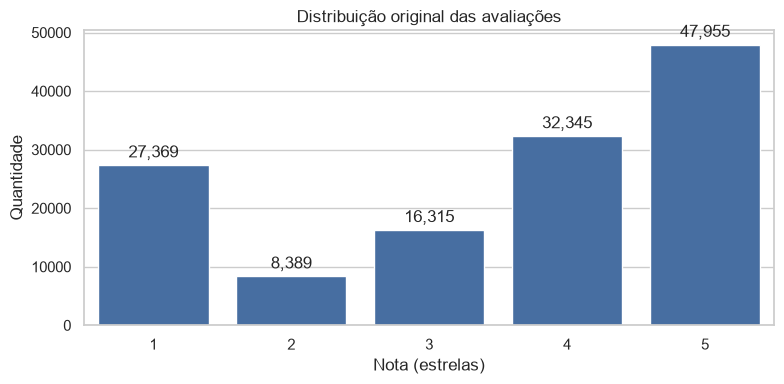

In [3]:
rating_counts = (
    df_raw["overall_rating"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("estrelas")
    .to_frame("quantidade")
)
rating_counts["percentual"] = 100 * rating_counts["quantidade"] / len(df_raw)

quality = pd.Series({
    "linhas": len(df_raw),
    "colunas": df_raw.shape[1],
    "textos ausentes": int(df_raw["review_text"].isna().sum()),
    "período inicial": df_raw["submission_date"].min(),
    "período final": df_raw["submission_date"].max(),
}, name="valor").to_frame()

display(quality)
display(rating_counts.style.format({"percentual": "{:.2f}%"}))

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=rating_counts.index.astype(str), y=rating_counts["quantidade"], ax=ax, color="#386cb0")
ax.set(title="Distribuição original das avaliações", xlabel="Nota (estrelas)", ylabel="Quantidade")
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "distribuicao_estrelas.png", dpi=160, bbox_inches="tight")
plt.show()

**Leitura do balanceamento.** As notas altas predominam: 4 e 5 estrelas formam a classe positiva majoritária. Logo, a acurácia isolada pode esconder baixo desempenho na classe negativa; por isso serão reportadas métricas macro e a matriz de confusão.

In [4]:
# Construção do corpus binário e auditoria das exclusões.
binary = df_raw.loc[
    df_raw["overall_rating"].isin([1, 2, 4, 5]),
    ["overall_rating", "review_text"],
].copy()

n_before = len(binary)
binary = binary.dropna(subset=["review_text"])
binary["review_text"] = binary["review_text"].astype(str).str.strip()
binary = binary[binary["review_text"].ne("")]
n_nonempty = len(binary)
binary["sentiment"] = (binary["overall_rating"] >= 4).astype(int)

# Remove duplicatas antes da divisão para impedir o mesmo texto em treino e teste.
n_duplicates = int(binary.duplicated(subset=["review_text"]).sum())
binary = binary.drop_duplicates(subset=["review_text"], keep="first").reset_index(drop=True)

audit = pd.Series({
    "linhas com notas 1, 2, 4 ou 5": n_before,
    "linhas após remover texto vazio": n_nonempty,
    "duplicatas exatas removidas": n_duplicates,
    "corpus binário final": len(binary),
}, name="quantidade").to_frame()
display(audit)

class_distribution = (
    binary["sentiment"].value_counts().sort_index()
    .rename(index={0: "negativa", 1: "positiva"})
    .rename("quantidade").to_frame()
)
class_distribution["percentual"] = 100 * class_distribution["quantidade"] / len(binary)
display(class_distribution.style.format({"percentual": "{:.2f}%"}))

,quantidade
"linhas com notas 1, 2, 4 ou 5",116058
linhas após remover texto vazio,113088
duplicatas exatas removidas,2206
corpus binário final,110882


,quantidade,percentual
sentiment,,
negativa,32601,29.40%
positiva,78281,70.60%


### 1.2 Divisão treino–teste

A amostragem e a divisão são estratificadas. Assim, treino e teste preservam o desbalanceamento natural do corpus. A amostra limita somente o custo computacional; não balanceamos artificialmente o teste.

In [5]:
if len(binary) > MAX_MODEL_ROWS:
    model_df, _ = train_test_split(
        binary,
        train_size=MAX_MODEL_ROWS,
        stratify=binary["sentiment"],
        random_state=RANDOM_STATE,
    )
else:
    model_df = binary.copy()

model_df = model_df.reset_index(drop=True)
train_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    stratify=model_df["sentiment"],
    random_state=RANDOM_STATE,
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    "conjunto": ["treino", "teste"],
    "n": [len(train_df), len(test_df)],
    "negativas": [(train_df.sentiment == 0).sum(), (test_df.sentiment == 0).sum()],
    "positivas": [(train_df.sentiment == 1).sum(), (test_df.sentiment == 1).sum()],
})
split_summary["% positivas"] = 100 * split_summary["positivas"] / split_summary["n"]
display(split_summary.style.format({"% positivas": "{:.2f}%"}))

assert set(train_df["review_text"]).isdisjoint(set(test_df["review_text"]))
print("Verificação: nenhum texto idêntico aparece nos dois conjuntos.")

,conjunto,n,negativas,positivas,% positivas
0,treino,24000,7056,16944,70.60%
1,teste,6000,1764,4236,70.60%


Verificação: nenhum texto idêntico aparece nos dois conjuntos.


## 2. Pré-processamento com NLTK e spaCy

Etapas aplicadas:

1. normalização Unicode NFKC e conversão para minúsculas;
2. remoção de HTML, URLs e caracteres que não sejam letras;
3. tokenização e lematização com o modelo português `pt_core_news_sm` do spaCy;
4. remoção de stopwords portuguesas do NLTK e tokens de um caractere.

As negações `não`, `nem`, `nunca`, `jamais` e `sem` são **preservadas**, pois removê-las inverteria ou enfraqueceria o sentimento. Acentos também são preservados para não confundir palavras portuguesas. A lematização reduz variações flexionais (`gostei`, `gostando` etc.) sem usar informação dos rótulos. O spaCy aqui não classifica sentimentos: ele apenas realiza análise linguística.

In [6]:
nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("portuguese"))
NEGATIONS = {"não", "nem", "nunca", "jamais", "sem"}
STOPWORDS -= NEGATIONS

try:
    nlp = spacy.load("pt_core_news_sm", disable=["parser", "ner"])
except OSError as exc:
    raise OSError(
        "Modelo pt_core_news_sm ausente. Execute: python -m spacy download pt_core_news_sm"
    ) from exc

HTML_RE = re.compile(r"<[^>]+>")
URL_RE = re.compile(r"https?://\S+|www\.\S+")
NON_LETTER_RE = re.compile(r"[^a-záàâãéèêíïóôõöúçñ\s]", flags=re.IGNORECASE)
SPACE_RE = re.compile(r"\s+")

def basic_normalize(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text)).lower()
    text = HTML_RE.sub(" ", text)
    text = URL_RE.sub(" ", text)
    text = NON_LETTER_RE.sub(" ", text)
    return SPACE_RE.sub(" ", text).strip()

def preprocess_texts(texts, batch_size=256):
    normalized = (basic_normalize(text) for text in texts)
    processed = []
    for doc in nlp.pipe(normalized, batch_size=batch_size):
        terms = []
        for token in doc:
            lemma = token.lemma_.lower().strip() or token.lower_.strip()
            if token.is_alpha and len(lemma) > 1 and lemma not in STOPWORDS:
                terms.append(lemma)
        processed.append(" ".join(terms))
    return processed

demo = pd.DataFrame({
    "original": ["Não gostei dos produtos! Chegaram atrasados.", "Ótima compra, recomendo muito!!!"],
})
demo["processado"] = preprocess_texts(demo["original"])
display(demo)

,original,processado
0,Não gostei dos produtos! Chegaram atrasados.,não gostar de o produto chegar atrasado
1,"Ótima compra, recomendo muito!!!",ótima compra recomendar


In [7]:
start = perf_counter()
X_train_text = preprocess_texts(train_df["review_text"])
X_test_text = preprocess_texts(test_df["review_text"])
y_train = train_df["sentiment"].to_numpy()
y_test = test_df["sentiment"].to_numpy()

# Textos que ficam vazios após a limpeza são mantidos como vetores zero; isso evita
# selecionar exemplos com base em qualquer informação do teste.
print(f"Pré-processamento concluído em {perf_counter() - start:.1f}s")
print(f"Textos vazios após limpeza — treino: {sum(not x for x in X_train_text)}, teste: {sum(not x for x in X_test_text)}")

Pré-processamento concluído em 47.5s
Textos vazios após limpeza — treino: 20, teste: 4


## 3. Representações vetoriais

**Bag of Words (BoW)** registra contagens dos termos. É simples e preserva frequência absoluta, mas palavras muito frequentes podem dominar o vetor.  
**TF-IDF** combina frequência no documento com raridade no corpus de treino, reduzindo o peso de termos presentes em muitos textos. Com normalização L2 e frequência sublinear, tende a favorecer termos mais discriminativos e modelos lineares.

Ambas são representações esparsas, ignoram ordem global e usam o mesmo limite de 8.000 atributos. Incluímos unigramas e bigramas para capturar expressões como `não gostar`; `min_df=2` elimina termos que ocorreram em um único texto de treino. O limite também torna a comparação computacionalmente justa.

In [8]:
vectorizers = {
    "BoW": CountVectorizer(
        max_features=MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        lowercase=False,
        token_pattern=r"(?u)\b\w+\b",
        dtype=np.float32,
    ),
    "TF-IDF": TfidfVectorizer(
        max_features=MAX_FEATURES,
        ngram_range=(1, 2),
        min_df=2,
        lowercase=False,
        token_pattern=r"(?u)\b\w+\b",
        sublinear_tf=True,
        norm="l2",
        dtype=np.float32,
    ),
}

vectorized = {}
for representation, vectorizer in vectorizers.items():
    Xtr = vectorizer.fit_transform(X_train_text)  # fit SOMENTE no treino
    Xte = vectorizer.transform(X_test_text)
    vectorized[representation] = (Xtr, Xte)
    density = Xtr.nnz / (Xtr.shape[0] * Xtr.shape[1])
    print(f"{representation:7s}: treino={Xtr.shape}, teste={Xte.shape}, densidade={density:.4%}")

assert all(pair[0].shape[1] <= MAX_FEATURES for pair in vectorized.values())

BoW    : treino=(24000, 8000), teste=(6000, 8000), densidade=0.2407%


TF-IDF : treino=(24000, 8000), teste=(6000, 8000), densidade=0.2407%


## 4. Treinamento dos cinco classificadores

- **Multinomial Naive Bayes:** baseline probabilístico natural para contagens não negativas.
- **Regressão Logística:** classificador linear regularizado; `class_weight='balanced'` reduz o viés da classe majoritária.
- **SVM linear:** `LinearSVC`, apropriado para muitos atributos esparsos e significativamente mais viável que um kernel não linear.
- **Random Forest:** 150 árvores, paralelismo e balanceamento por bootstrap; profundidade e folha são regularizadas para conter custo/sobreajuste.
- **Gradient Boosting:** 100 estimadores; `max_features='sqrt'` limita os atributos inspecionados em cada divisão, necessário para alta dimensionalidade esparsa.

As alterações em relação aos padrões são de reprodutibilidade, convergência, desbalanceamento ou viabilidade — não resultam de ajuste no conjunto de teste.

In [9]:
models = {
    "Naive Bayes": MultinomialNB(alpha=1.0),
    "Regressão Logística": LogisticRegression(
        max_iter=1_000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SVM": LinearSVC(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=35,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=RANDOM_STATE,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        max_features="sqrt",
        random_state=RANDOM_STATE,
    ),
}

rows = []
predictions = {}
confusion_matrices = {}
fitted_models = {}

for representation, (Xtr, Xte) in vectorized.items():
    for model_name, prototype in models.items():
        model = clone(prototype)
        start = perf_counter()
        model.fit(Xtr, y_train)
        fit_seconds = perf_counter() - start
        y_pred = model.predict(Xte)

        precision, recall, f1, _ = precision_recall_fscore_support(
            y_test, y_pred, average="macro", zero_division=0
        )
        key = (representation, model_name)
        predictions[key] = y_pred
        confusion_matrices[key] = confusion_matrix(y_test, y_pred, labels=[0, 1])
        fitted_models[key] = model
        rows.append({
            "Representação": representation,
            "Classificador": model_name,
            "Acurácia": accuracy_score(y_test, y_pred),
            "Precisão (macro)": precision,
            "Revocação (macro)": recall,
            "F1 (macro)": f1,
            "Treino (s)": fit_seconds,
        })
        print(f"✓ {representation:7s} | {model_name:20s} | F1-macro={f1:.4f} | {fit_seconds:.1f}s")

results = (
    pd.DataFrame(rows)
    .sort_values(["F1 (macro)", "Acurácia"], ascending=False)
    .reset_index(drop=True)
)
results.to_csv(ARTIFACTS_DIR / "resultados_comparativos.csv", index=False)
display(results.style.format({
    "Acurácia": "{:.4f}",
    "Precisão (macro)": "{:.4f}",
    "Revocação (macro)": "{:.4f}",
    "F1 (macro)": "{:.4f}",
    "Treino (s)": "{:.2f}",
}).highlight_max(subset=["Acurácia", "Precisão (macro)", "Revocação (macro)", "F1 (macro)"], color="#b7e4c7"))

✓ BoW     | Naive Bayes          | F1-macro=0.9150 | 0.0s
✓ BoW     | Regressão Logística  | F1-macro=0.9241 | 0.2s


✓ BoW     | SVM                  | F1-macro=0.9081 | 1.0s


✓ BoW     | Random Forest        | F1-macro=0.8948 | 0.5s


✓ BoW     | Gradient Boosting    | F1-macro=0.8345 | 0.2s
✓ TF-IDF  | Naive Bayes          | F1-macro=0.9154 | 0.0s
✓ TF-IDF  | Regressão Logística  | F1-macro=0.9207 | 0.0s
✓ TF-IDF  | SVM                  | F1-macro=0.9207 | 0.1s


✓ TF-IDF  | Random Forest        | F1-macro=0.8918 | 0.5s


✓ TF-IDF  | Gradient Boosting    | F1-macro=0.8339 | 0.3s


,Representação,Classificador,Acurácia,Precisão (macro),Revocação (macro),F1 (macro),Treino (s)
0,BoW,Regressão Logística,0.9365,0.9209,0.9276,0.9241,0.16
1,TF-IDF,Regressão Logística,0.9323,0.9108,0.9331,0.9207,0.03
2,TF-IDF,SVM,0.9332,0.9148,0.9274,0.9207,0.06
3,TF-IDF,Naive Bayes,0.9298,0.9157,0.9152,0.9154,0.00
4,BoW,Naive Bayes,0.9277,0.9061,0.9258,0.9150,0.01
5,BoW,SVM,0.9235,0.9071,0.9091,0.9081,1.04
6,BoW,Random Forest,0.9100,0.8850,0.9073,0.8948,0.48
7,TF-IDF,Random Forest,0.9070,0.8809,0.9062,0.8918,0.49
8,BoW,Gradient Boosting,0.8762,0.8912,0.8063,0.8345,0.24
9,TF-IDF,Gradient Boosting,0.8755,0.8892,0.8061,0.8339,0.31


## 5. Avaliação comparativa

A seleção do melhor modelo usa **F1 macro**, definida antes dos experimentos. Em caso de empate, usa-se acurácia. Isso evita escolher um modelo que apenas favorece a classe positiva majoritária.

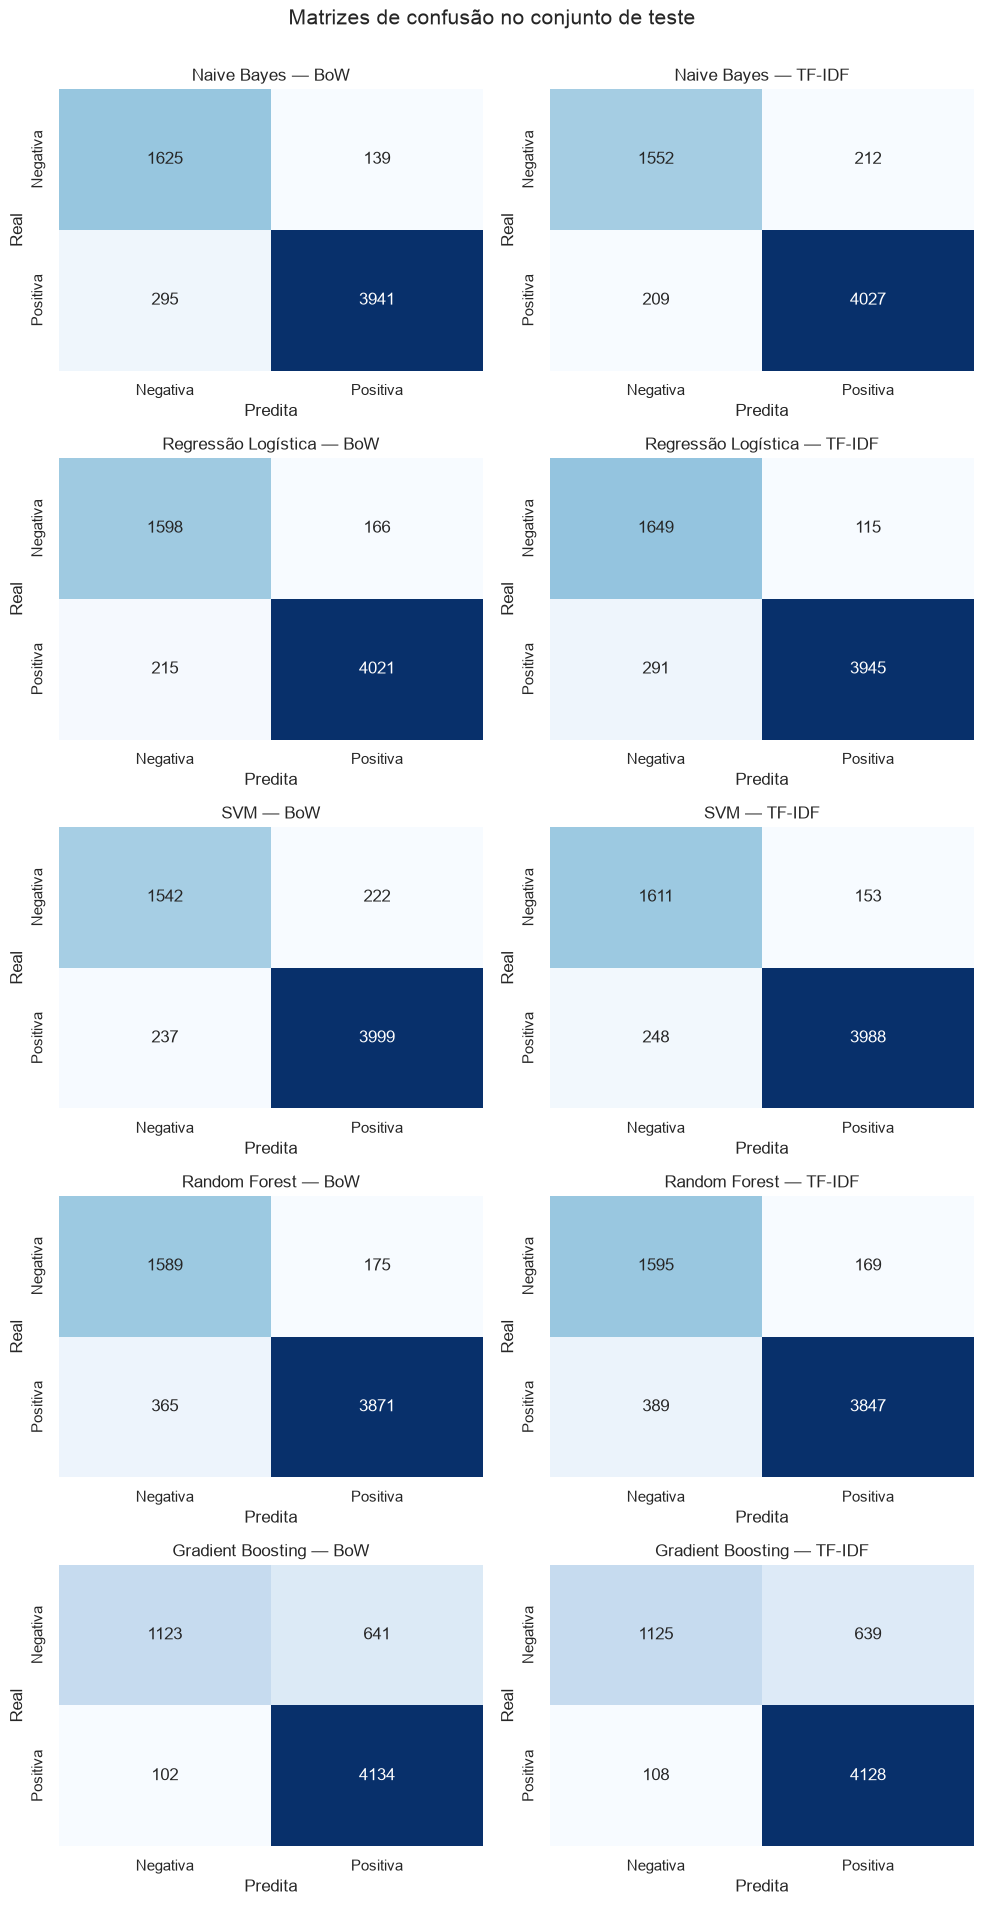

In [10]:
# Todas as 10 matrizes, requisito da avaliação de cada combinação.
fig, axes = plt.subplots(5, 2, figsize=(10, 19))
for row_idx, model_name in enumerate(models):
    for col_idx, representation in enumerate(vectorizers):
        ax = axes[row_idx, col_idx]
        cm = confusion_matrices[(representation, model_name)]
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                    xticklabels=["Negativa", "Positiva"], yticklabels=["Negativa", "Positiva"])
        ax.set_title(f"{model_name} — {representation}")
        ax.set_xlabel("Predita")
        ax.set_ylabel("Real")
fig.suptitle("Matrizes de confusão no conjunto de teste", y=1.002, fontsize=15)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "matrizes_confusao_todas.png", dpi=160, bbox_inches="tight")
plt.show()

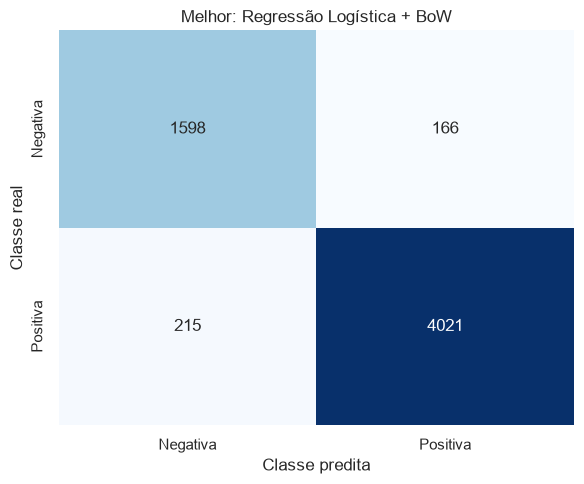

Melhor combinação por F1 macro: Regressão Logística + BoW


,valor
Representação,BoW
Classificador,Regressão Logística
Acurácia,0.9365
Precisão (macro),0.920883
Revocação (macro),0.92757
F1 (macro),0.924126
Treino (s),0.164763


In [11]:
best = results.iloc[0]
best_key = (best["Representação"], best["Classificador"])
best_pred = predictions[best_key]
best_cm = confusion_matrices[best_key]

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    ax=ax,
    xticklabels=["Negativa", "Positiva"],
    yticklabels=["Negativa", "Positiva"],
)
ax.set(
    title=f"Melhor: {best['Classificador']} + {best['Representação']}",
    xlabel="Classe predita",
    ylabel="Classe real",
)
fig.tight_layout()
fig.savefig(ARTIFACTS_DIR / "matriz_confusao_melhor_modelo.png", dpi=180, bbox_inches="tight")
plt.show()

print(f"Melhor combinação por F1 macro: {best['Classificador']} + {best['Representação']}")
display(best.to_frame("valor"))

In [12]:
# Efeito médio da representação sobre os cinco classificadores.
representation_summary = (
    results.groupby("Representação")[["Acurácia", "Precisão (macro)", "Revocação (macro)", "F1 (macro)"]]
    .mean()
    .sort_values("F1 (macro)", ascending=False)
)
display(representation_summary.style.format("{:.4f}"))

pivot_f1 = results.pivot(index="Classificador", columns="Representação", values="F1 (macro)")
pivot_f1["Δ TF-IDF − BoW"] = pivot_f1["TF-IDF"] - pivot_f1["BoW"]
display(pivot_f1.sort_values("Δ TF-IDF − BoW", ascending=False).style.format("{:+.4f}"))

,Acurácia,Precisão (macro),Revocação (macro),F1 (macro)
Representação,,,,
TF-IDF,0.9156,0.9023,0.8976,0.8965
BoW,0.9148,0.9021,0.8952,0.8953


Representação,BoW,TF-IDF,Δ TF-IDF − BoW
Classificador,,,
SVM,+0.9081,+0.9207,+0.0126
Naive Bayes,+0.9150,+0.9154,+0.0004
Gradient Boosting,+0.8345,+0.8339,-0.0006
Random Forest,+0.8948,+0.8918,-0.0030
Regressão Logística,+0.9241,+0.9207,-0.0034


### 5.1 Análise de erros

Examinamos falsos positivos (avaliação negativa prevista como positiva) e falsos negativos (positiva prevista como negativa). A amostra abaixo é determinística e permite observar negação, avaliações mistas, textos curtos, ironia e divergência entre a nota e o conteúdo.

In [13]:
errors = test_df[["overall_rating", "review_text", "sentiment"]].copy()
errors["predito"] = best_pred
errors = errors[errors["sentiment"] != errors["predito"]].copy()
errors["tipo_erro"] = np.where(
    (errors["sentiment"] == 0) & (errors["predito"] == 1),
    "Falso positivo",
    "Falso negativo",
)

error_sample = (
    errors.groupby("tipo_erro", group_keys=False)
    .sample(n=min(5, errors["tipo_erro"].value_counts().min()), random_state=RANDOM_STATE)
    .sort_values("tipo_erro")
)
errors.to_csv(ARTIFACTS_DIR / "erros_melhor_modelo.csv", index=False)
display(error_sample[["tipo_erro", "overall_rating", "review_text"]].style.set_properties(
    subset=["review_text"], **{"white-space": "pre-wrap", "text-align": "left"}
))
print(f"Total de erros do melhor modelo: {len(errors):,} em {len(test_df):,} exemplos de teste")

,tipo_erro,overall_rating,review_text
5647,Falso negativo,5,"É caro, mas dura muito. É possível revender depois de alguns anos de uso, não trava e não precisa ficar reiniciando!"
5951,Falso negativo,5,Qualidade e preço justo. Mas falta a capinha para guardar a frente destacável.
3870,Falso negativo,5,"Produto é muito lindo, sei que esse tipo de material não dura muito, mais que a beleza me encantou, a encantou"
4949,Falso negativo,5,Meu rosto começos a receber os resultados depois de 2 semanas. Eu estou usando para proteger a pele aplicando antes de maquiagem. No meu trabalho preciso estar maquiada o tempo todo e este produto tem protegido minha pele.
358,Falso negativo,4,mercadoria foi enviada errada conforme o pedido palheta fiat uno 93 trazeira enviaram a dianteira já pedi informação de como trocar até agora não me informaram
111,Falso positivo,1,Comprei esse perfume porque eu uso ele fazem anos e a fixação do mesmo sempre foi muito boa durando horas. Agora esse em questão não dura 20 minutos na pele.
5330,Falso positivo,2,"Produto com boa qualidade de som, de conexão e botões de comando úteis. Porém, os anéis de orelha e os protetores intra-auriculares não proporcionam firmeza e estabilidade do fone dentro do ouvido durante o uso, pois, toda a estrutura do fone é muito grande e impede que o mesmo se encaixe perfeitamente ao ouvido, tornando o mesmo uma escolha ruim para quem quer ouvir música durante a prática esportiva. Além do mais, mesmo seguindo as instruções de primeira carga, a bateria proporciona apenas 3 horas de uso, ao contrário das 5 horas prometidas."
3026,Falso positivo,1,Não compensa. aqui na minha cidade consegue comprar produto melhor qualidade com menos valor.
642,Falso positivo,2,"O produto chegou antes do esperado, bem embalado. Um bom trabalho da americanas.com; por outro lado o jogo diverte, mas pela desconsideração da Warner Bros para com o público alvo, a história acabou ficando incompleta. Há também a presença de alguns erros no software (como bugs e lags), porém nada que atrapalhe a conclusão do jogo."
5318,Falso positivo,2,"Utilizo óleo de uma outra marca e o frasco de 30 ml parece ser menor, apesar do aroma muito bom não recomendo devido o frasco ter um tamanho de 15 ml"


Total de erros do melhor modelo: 381 em 6,000 exemplos de teste


## 6. Validações e exportação

As asserções abaixo funcionam como testes de integridade da entrega: dez resultados, métricas válidas, duas classes presentes e nenhum vazamento de texto idêntico.

In [14]:
metric_cols = ["Acurácia", "Precisão (macro)", "Revocação (macro)", "F1 (macro)"]
assert len(results) == 10
assert results["Representação"].nunique() == 2
assert results["Classificador"].nunique() == 5
assert results[metric_cols].apply(lambda col: col.between(0, 1).all()).all()
assert set(np.unique(y_test)) == {0, 1}
assert set(train_df["review_text"]).isdisjoint(set(test_df["review_text"]))

run_summary = {
    "random_state": RANDOM_STATE,
    "model_rows": len(model_df),
    "train_rows": len(train_df),
    "test_rows": len(test_df),
    "best_representation": str(best["Representação"]),
    "best_classifier": str(best["Classificador"]),
    "best_f1_macro": float(best["F1 (macro)"]),
    "best_accuracy": float(best["Acurácia"]),
    "confusion_matrix": best_cm.tolist(),
}
(ARTIFACTS_DIR / "resumo_execucao.json").write_text(
    json.dumps(run_summary, ensure_ascii=False, indent=2), encoding="utf-8"
)
print("Todos os testes passaram. Artefatos salvos em artifacts/.")
print(json.dumps(run_summary, ensure_ascii=False, indent=2))

Todos os testes passaram. Artefatos salvos em artifacts/.
{
  "random_state": 42,
  "model_rows": 30000,
  "train_rows": 24000,
  "test_rows": 6000,
  "best_representation": "BoW",
  "best_classifier": "Regressão Logística",
  "best_f1_macro": 0.9241264358930947,
  "best_accuracy": 0.9365,
  "confusion_matrix": [
    [
      1598,
      166
    ],
    [
      215,
      4021
    ]
  ]
}


## 7. Conclusões

Os resultados numéricos acima devem ser interpretados em conjunto:

1. o melhor modelo é definido por F1 macro, não apenas por acurácia;
2. a tabela de médias e o delta por classificador mostram se o efeito de TF-IDF é consistente ou dependente do algoritmo;
3. as matrizes revelam qual classe concentra os erros;
4. os exemplos indicam limites das representações esparsas: contexto composicional, contraste (`produto bom, entrega péssima`), ironia, textos muito curtos e possível ruído entre nota e comentário.

Este baseline é adequado para a comparação futura com NLG porque tem protocolo explícito, teste isolado, representações clássicas e métricas reproduzíveis. As conclusões consolidadas com os valores executados encontram-se em `RELATORIO.md`.

**Limitação:** os resultados correspondem a uma amostra estratificada de 30 mil avaliações e a uma única divisão treino–teste. Pequenas diferenças entre modelos não devem ser interpretadas como evidência de superioridade estatística; também não foi realizada busca de hiperparâmetros, pois o foco é a comparação das representações.

### Referências

- Americanas Tech. [B2W-Reviews01 — repositório oficial](https://github.com/americanas-tech/b2w-reviews01).
- Real, L.; Oshiro, M.; Mafra, A. *B2W-Reviews01: an open product reviews corpus*. STIL, 2019. PDF disponível no repositório oficial.
- scikit-learn. [Feature extraction](https://scikit-learn.org/stable/modules/feature_extraction.html) e [supervised learning](https://scikit-learn.org/stable/supervised_learning.html).